In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(
    'youtube_hk_tw_final.csv',
    on_bad_lines='skip',
    encoding_errors='replace'
)

print(len(df))

140456


/tmp/ipykernel_4854/3516621142.py:1: DtypeWarning: Columns (13,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [ ]:
df = pd.read_csv('youtube_hk_tw_final.csv', on_bad_lines='warn', encoding_errors='replace')

/tmp/ipykernel_4854/1820958251.py:1: DtypeWarning: Columns (13,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('youtube_hk_tw_final.csv', on_bad_lines='warn', encoding_errors='replace')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140456 entries, 0 to 140455
Data columns (total 28 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   video_id                         140456 non-null  object 
 1   video_published_at               140456 non-null  object 
 2   video_trending__date             140456 non-null  object 
 3   video_trending_country           140456 non-null  object 
 4   channel_id                       140456 non-null  object 
 5   video_title                      140456 non-null  object 
 6   video_description                132482 non-null  object 
 7   video_default_thumbnail          140452 non-null  object 
 8   video_category_id                140212 non-null  object 
 9   video_tags                       104789 non-null  object 
 10  video_duration                   140452 non-null  object 
 11  video_dimension                  140452 non-null  object 
 12  vi

In [ ]:
critical_cols = ['video_category_id', 'video_view_count']
df = df.dropna(subset=critical_cols)

print(f'after drop na :{len(df)}')

after drop na :140209


In [ ]:
print(df.isnull().sum())

video_id                               0
video_published_at                     0
video_trending__date                   0
video_trending_country                 0
channel_id                             0
video_title                            0
video_description                   7802
video_default_thumbnail                0
video_category_id                      0
video_tags                         35453
video_duration                         0
video_dimension                        0
video_definition                       0
video_licensed_content                 0
video_view_count                       0
video_like_count                    1412
video_comment_count                  490
channel_title                          0
channel_description                12837
channel_custom_url                  6877
channel_published_at                   0
channel_country                    21907
channel_view_count                    32
channel_subscriber_count               0
channel_have_hid

In [ ]:
text_cols = ['video_description', 'video_tags', 'channel_description',
             'channel_custom_url', 'channel_localized_description']
df[text_cols] = df[text_cols].fillna("None")

In [ ]:
num_cols = ['video_like_count', 'video_comment_count', 'channel_view_count']
df[num_cols] = df[num_cols].fillna(0)

In [ ]:
df['channel_country'] = df['channel_country'].fillna("Unknown")

In [ ]:
print(df.isnull().sum().sum())

0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140209 entries, 0 to 140455
Data columns (total 28 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   video_id                         140209 non-null  object 
 1   video_published_at               140209 non-null  object 
 2   video_trending__date             140209 non-null  object 
 3   video_trending_country           140209 non-null  object 
 4   channel_id                       140209 non-null  object 
 5   video_title                      140209 non-null  object 
 6   video_description                140209 non-null  object 
 7   video_default_thumbnail          140209 non-null  object 
 8   video_category_id                140209 non-null  object 
 9   video_tags                       140209 non-null  object 
 10  video_duration                   140209 non-null  object 
 11  video_dimension                  140209 non-null  object 
 12  video_d

In [ ]:
df.to_csv('youtube_hktw_clean.csv', index=False)

In [ ]:
df = pd.read_csv('/content/youtube_hktw_clean.csv',keep_default_na=False,)
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140209 entries, 0 to 140208
Data columns (total 28 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   video_id                         140209 non-null  object 
 1   video_published_at               140209 non-null  object 
 2   video_trending__date             140209 non-null  object 
 3   video_trending_country           140209 non-null  object 
 4   channel_id                       140209 non-null  object 
 5   video_title                      140209 non-null  object 
 6   video_description                140209 non-null  object 
 7   video_default_thumbnail          140209 non-null  object 
 8   video_category_id                140209 non-null  object 
 9   video_tags                       140209 non-null  object 
 10  video_duration                   140209 non-null  object 
 11  video_dimension                  140209 non-null  object 
 12  vi

In [ ]:
pd.options.display.float_format = '{:.0f}'.format
print(df['video_view_count'].describe())

count      140209
mean      4169970
std      16641175
min           742
25%         56850
50%        278219
75%        933977
max     407522998
Name: video_view_count, dtype: float64


In [ ]:
def get_level(v):
    if v < 278219: return 1
    if v < 933977: return 2
    return 3

df['reach_level'] = df['video_view_count'].apply(get_level)

In [ ]:

df['video_published_at'] = pd.to_datetime(df['video_published_at'])

df['publish_hour'] = df['video_published_at'].dt.hour

df['publish_day_of_week'] = df['video_published_at'].dt.dayofweek

In [ ]:
print(df['video_category_id'].unique())

['Pets & Animals' 'People & Blogs' 'Entertainment' 'Gaming'
 'Howto & Style' 'Film & Animation' 'News & Politics' 'Autos & Vehicles'
 'Education' 'Music' 'Sports' 'Travel & Events' 'Comedy'
 'Science & Technology']


In [ ]:
category_map = {
    'Autos & Vehicles': 1,
    'Comedy': 2,
    'Education': 3,
    'Entertainment': 4,
    'Film & Animation': 5,
    'Gaming': 6,
    'Howto & Style': 7,
    'Music': 8,
    'News & Politics': 9,
    'People & Blogs': 10,
    'Pets & Animals': 11,
    'Science & Technology': 12,
    'Sports': 13,
    'Travel & Events': 14
}

checking_category_map = {v: k for k, v in category_map.items()}

print(f"number 8 is represent: {checking_category_map[8]}")


number 8 is represent: Music


In [ ]:
df['video_category_id'] = df['video_category_id'].map(category_map)

In [ ]:
print(df['video_category_id'].unique())

[11 10  4  6  7  5  9  1  3  8 13 14  2 12]


In [ ]:
print(df['video_category_id'].isnull().sum())

0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140209 entries, 0 to 140208
Data columns (total 31 columns):
 #   Column                           Non-Null Count   Dtype              
---  ------                           --------------   -----              
 0   video_id                         140209 non-null  object             
 1   video_published_at               140209 non-null  datetime64[ns, UTC]
 2   video_trending__date             140209 non-null  object             
 3   video_trending_country           140209 non-null  object             
 4   channel_id                       140209 non-null  object             
 5   video_title                      140209 non-null  object             
 6   video_description                140209 non-null  object             
 7   video_default_thumbnail          140209 non-null  object             
 8   video_category_id                140209 non-null  int64              
 9   video_tags                       140209 non-null  object   

In [ ]:
df['video_trending_country'] = df['video_trending_country'].map({'Hong Kong': 0, 'Taiwan': 1})
df['video_licensed_content'] = df['video_licensed_content'].astype(int)
df['channel_have_hidden_subscribers'] = df['channel_have_hidden_subscribers'].astype(int)

In [ ]:
df['video_definition'].unique()

array(['hd', 'sd'], dtype=object)

In [ ]:
df['video_definition'] = df['video_definition'].map({'hd': 1, 'sd': 0}).fillna(0).astype(int)

In [ ]:
df['title_length'] = df['video_title'].str.len()
df['tag_count'] = df['video_tags'].apply(lambda x: 0 if x in ["", "None"] else len(str(x).split('|')))

In [ ]:
!pip install isodate

In [ ]:
import isodate #用isodate將duration變做seconds

def duration_to_seconds(duration_str):
    try:
        return isodate.parse_duration(duration_str).total_seconds()
    except:
        return 0

df['duration_seconds'] = df['video_duration'].apply(duration_to_seconds)

In [ ]:
print(df['duration_seconds'].head(10))

0   11
1   15
2   56
3   18
4   13
5   40
6   17
7   10
8   22
9   19
Name: duration_seconds, dtype: float64


In [ ]:
df['is_shorts'] = (df['duration_seconds'] <= 60).astype(int)
print(df['is_shorts'].value_counts())

is_shorts
0    102846
1     37363
Name: count, dtype: int64


In [ ]:
df = df.sort_values('video_trending__date').drop_duplicates(subset=['video_id'], keep='first')
print(f"after duplicates drop, the total number of video：{len(df)}")

after duplicates drop, the total number of video：24086


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24086 entries, 0 to 139934
Data columns (total 35 columns):
 #   Column                           Non-Null Count  Dtype              
---  ------                           --------------  -----              
 0   video_id                         24086 non-null  object             
 1   video_published_at               24086 non-null  datetime64[ns, UTC]
 2   video_trending__date             24086 non-null  object             
 3   video_trending_country           24086 non-null  int64              
 4   channel_id                       24086 non-null  object             
 5   video_title                      24086 non-null  object             
 6   video_description                24086 non-null  object             
 7   video_default_thumbnail          24086 non-null  object             
 8   video_category_id                24086 non-null  int64              
 9   video_tags                       24086 non-null  object             
 10  vi

In [ ]:
#用今日日子減去channel_published day計算出channel成立多久
df['channel_published_at'] = pd.to_datetime(df['channel_published_at'], format='ISO8601', utc=True)

today = pd.to_datetime('2026-01-24', utc=True)

df['channel_age_days'] = (today - df['channel_published_at']).dt.days

df['channel_age_days'] = df['channel_age_days'].fillna(0).astype(int)

print (df['channel_age_days'].head(10))

0      1530
55      617
56      652
58     1387
60     1079
61     4629
48     3179
30     1641
29     5141
128    2242
Name: channel_age_days, dtype: int64


In [ ]:
df['channel_country_int'] = df['channel_country'].astype('category').cat.codes

In [ ]:
df.to_csv('youtube_hktw_cleaned.csv', index=False)

In [16]:
df = pd.read_csv('youtube_hktw_cleaned.csv',keep_default_na=False)
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24086 entries, 0 to 24085
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   video_id                         24086 non-null  object 
 1   video_published_at               24086 non-null  object 
 2   video_trending__date             24086 non-null  object 
 3   video_trending_country           24086 non-null  int64  
 4   channel_id                       24086 non-null  object 
 5   video_title                      24086 non-null  object 
 6   video_description                24086 non-null  object 
 7   video_default_thumbnail          24086 non-null  object 
 8   video_category_id                24086 non-null  int64  
 9   video_tags                       24086 non-null  object 
 10  video_duration                   24086 non-null  object 
 11  video_dimension                  24086 non-null  object 
 12  video_definition  

In [18]:
print(df.loc[[3, 1703], ['channel_country', 'channel_country_int']])

     channel_country  channel_country_int
3          Hong Kong                   18
1703       Hong Kong                   18


In [11]:
country_mapping = df[['channel_country', 'channel_country_int']].drop_duplicates().sort_values('channel_country_int')

# 打印結果
print("--- 國家與數字對照表 ---")
print(country_mapping.to_string(index=False))

--- 國家與數字對照表 ---
     channel_country  channel_country_int
           Argentina                    0
           Australia                    1
             Austria                    2
          Azerbaijan                    3
             Belgium                    4
              Brazil                    5
              Canada                    6
               Chile                    7
            Colombia                    8
              Cyprus                    9
             Denmark                   10
               Egypt                   11
         El Salvador                   12
             Finland                   13
              France                   14
             Georgia                   15
             Germany                   16
               Ghana                   17
           Hong Kong                   18
               India                   19
           Indonesia                   20
             Ireland                   21
               It

In [ ]:
features = [
    'video_category_id', 'video_trending_country', 'publish_hour',
    'publish_day_of_week', 'title_length', 'tag_count',
    'channel_subscriber_count', 'video_definition',
    'video_licensed_content', 'channel_have_hidden_subscribers',
    'is_shorts'
]

X = df[features]
y = df['reach_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.join(y_train).to_csv('youtube_train_v1.csv', index=False)
X_test.join(y_test).to_csv('youtube_test_v1.csv', index=False)

print(f"Train: {len(X_train)},Test: {len(X_test)}")

Train: 19268,Test: 4818


In [ ]:
#未加新features
train_df = pd.read_csv('/content/youtube_train_24k.csv')
test_df = pd.read_csv('/content/youtube_test_24k.csv')

X = train_df.drop('reach_level',axis = 1)
y = train_df['reach_level']

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators= 1000,
    learning_rate = 0.05,
    max_depth = 6,
    early_stopping_rounds = 50,
    tree_method = 'auto',
    device = 'cpu',
    random_state = 42
)

model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose = 100
)

X_test = test_df.drop('reach_level', axis=1)
predictions = model.predict(X_test)

val_preds = model.predict(X_val)
val_preds_labels = val_preds.round().astype(int)
print("Report：")
print(classification_report(y_val, val_preds_labels))

[0]	validation_0-rmse:0.57596
[100]	validation_0-rmse:0.39425
[200]	validation_0-rmse:0.39202
[273]	validation_0-rmse:0.39211
Report：
              precision    recall  f1-score   support

           1       0.93      0.94      0.94      3165
           2       0.40      0.51      0.45       386
           3       0.87      0.44      0.58       303

    accuracy                           0.86      3854
   macro avg       0.73      0.63      0.65      3854
weighted avg       0.87      0.86      0.86      3854



[0]	validation_0-mlogloss:1.07502
[100]	validation_0-mlogloss:0.50483
[200]	validation_0-mlogloss:0.46017
[300]	validation_0-mlogloss:0.44591
[400]	validation_0-mlogloss:0.43412
[500]	validation_0-mlogloss:0.42412
[600]	validation_0-mlogloss:0.41728
[700]	validation_0-mlogloss:0.41098
[800]	validation_0-mlogloss:0.40739
[900]	validation_0-mlogloss:0.40570
[1000]	validation_0-mlogloss:0.40523
[1004]	validation_0-mlogloss:0.40523

Report：
              precision    recall  f1-score   support

           1       0.95      0.90      0.92      3165
           2       0.37      0.55      0.44       386
           3       0.66      0.62      0.64       303

    accuracy                           0.84      3854
   macro avg       0.66      0.69      0.67      3854
weighted avg       0.87      0.84      0.85      3854



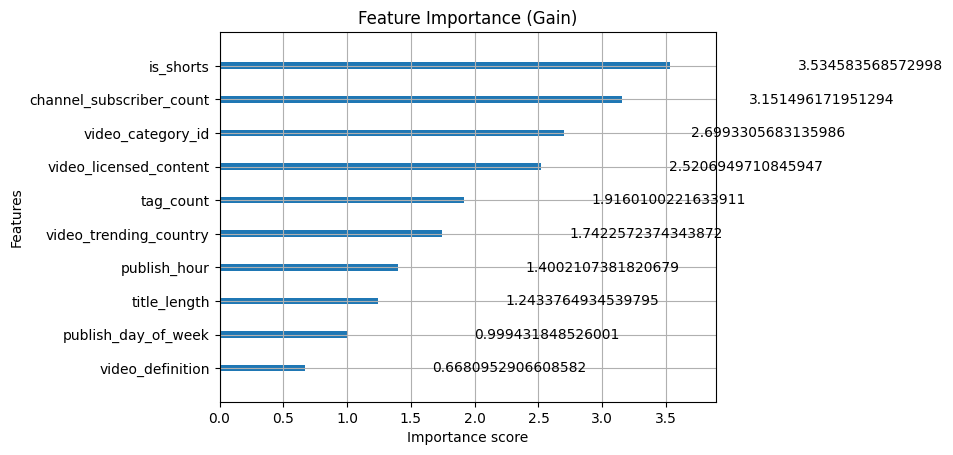

In [ ]:
#改用classifier, y要打-1 reach level先會show 1,2,3
X = train_df.drop('reach_level',axis = 1)
y = train_df['reach_level'] -1

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = xgb.XGBClassifier(
    n_estimators= 1500,
    learning_rate = 0.03,
    max_depth = 8,
    min_child_weight=1,
    early_stopping_rounds = 50,
    tree_method = 'auto',
    device = 'cpu',
    random_state = 42
)

model.fit(
    X_train, y_train,
    sample_weight=weights,
    eval_set=[(X_val, y_val)],
    verbose=100
)

X_test = test_df.drop('reach_level', axis=1)
predictions = model.predict(X_test)

val_preds = model.predict(X_val)
val_preds_labels = val_preds.round().astype(int)
print("\nReport：")
print(classification_report(y_val +1, val_preds_labels +1))

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Feature Importance (Gain)")
plt.show()


In [ ]:
#Feature排名榜
importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances
})

feature_importance_df['Importance_Percentage'] = (feature_importance_df['Importance_Score'] * 100).round(2)
feature_importance_df = feature_importance_df.sort_values(by='Importance_Percentage', ascending=False)

print("\nFeature排名榜")
print(feature_importance_df[['Feature', 'Importance_Percentage']])


Feature排名榜
                            Feature  Importance_Percentage
10                        is_shorts              17.780001
6          channel_subscriber_count              15.860000
0                 video_category_id              13.580000
8            video_licensed_content              12.680000
5                         tag_count               9.640000
1            video_trending_country               8.770000
2                      publish_hour               7.040000
4                      title_length               6.260000
3               publish_day_of_week               5.030000
7                  video_definition               3.360000
9   channel_have_hidden_subscribers               0.000000


[0]	validation_0-mlogloss:1.07502
[100]	validation_0-mlogloss:0.50481
[200]	validation_0-mlogloss:0.46027
[300]	validation_0-mlogloss:0.44494
[400]	validation_0-mlogloss:0.43180
[500]	validation_0-mlogloss:0.42069
[600]	validation_0-mlogloss:0.41547
[700]	validation_0-mlogloss:0.41045
[800]	validation_0-mlogloss:0.40685
[841]	validation_0-mlogloss:0.40689

Report:
              precision    recall  f1-score   support

           1       0.95      0.89      0.92      3165
           2       0.38      0.58      0.46       386
           3       0.66      0.63      0.64       303

    accuracy                           0.84      3854
   macro avg       0.66      0.70      0.68      3854
weighted avg       0.87      0.84      0.85      3854



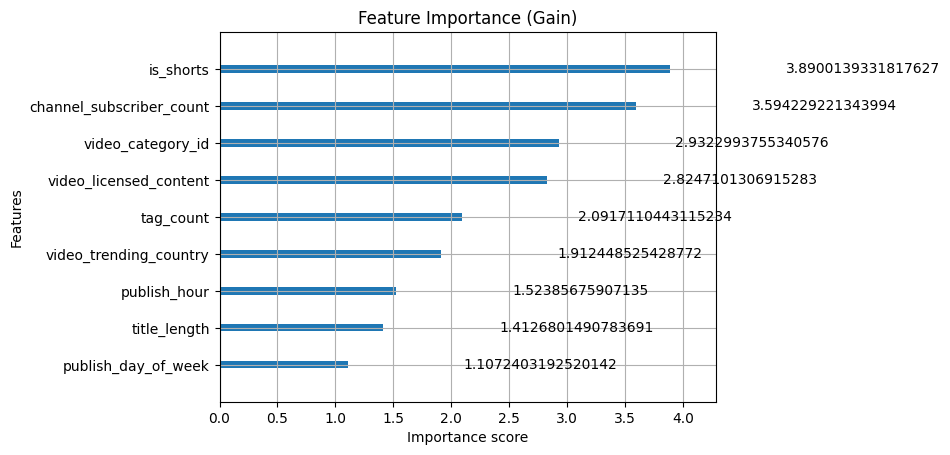

In [ ]:
#嘗試drop走冇用既columns
drop_cols = ['reach_level', 'channel_have_hidden_subscribers', 'video_definition']

X = train_df.drop(columns=drop_cols)
y = train_df['reach_level'] -1

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = xgb.XGBClassifier(
    n_estimators= 1500,
    learning_rate = 0.03,
    max_depth = 8,
    min_child_weight=1,
    early_stopping_rounds = 50,
    tree_method = 'auto',
    device = 'cpu',
    random_state = 42
)

model.fit(
    X_train, y_train,
    sample_weight=weights,
    eval_set=[(X_val, y_val)],
    verbose=100
)

X_test = test_df.drop(columns=drop_cols)
predictions = model.predict(X_test)

val_preds = model.predict(X_val)
val_preds_labels = val_preds.round().astype(int)
print("\nReport:")
print(classification_report(y_val +1, val_preds_labels +1))

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Feature Importance (Gain)")
plt.show()

[0]	validation_0-mlogloss:1.08159
[100]	validation_0-mlogloss:0.50922
[200]	validation_0-mlogloss:0.43373
[300]	validation_0-mlogloss:0.41363
[400]	validation_0-mlogloss:0.40566
[500]	validation_0-mlogloss:0.40158
[600]	validation_0-mlogloss:0.39921
[700]	validation_0-mlogloss:0.39815
[724]	validation_0-mlogloss:0.39857

Report:
              precision    recall  f1-score   support

           1       0.94      0.90      0.92      3165
           2       0.40      0.56      0.47       386
           3       0.68      0.61      0.64       303

    accuracy                           0.85      3854
   macro avg       0.67      0.69      0.68      3854
weighted avg       0.87      0.85      0.86      3854



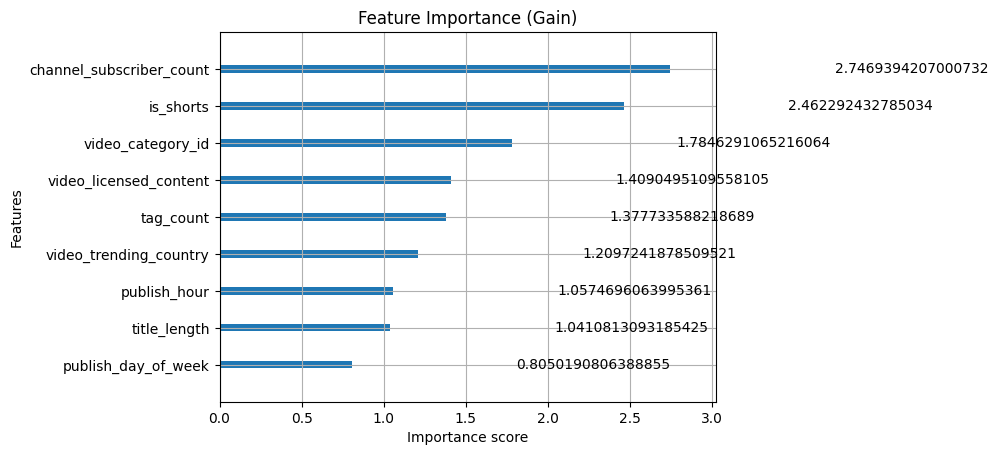

In [ ]:
#再做hyperturning 試下將macro avg推高
X = train_df.drop(columns=drop_cols)
y = train_df['reach_level'] -1

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=42)

weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = xgb.XGBClassifier(
    n_estimators= 1500,
    learning_rate = 0.02,
    max_depth = 10,
    min_child_weight=0.1,
    early_stopping_rounds = 50,
    tree_method = 'auto',
    device = 'cpu',
    random_state = 42
)

model.fit(
    X_train, y_train,
    sample_weight=weights,
    eval_set=[(X_val, y_val)],
    verbose=100
)

X_test = test_df.drop(columns=drop_cols)
predictions = model.predict(X_test)

val_preds = model.predict(X_val)
val_preds_labels = val_preds.round().astype(int)
print("\nReport:")
print(classification_report(y_val +1, val_preds_labels +1))

xgb.plot_importance(model, importance_type='gain', max_num_features=10)
plt.title("Feature Importance (Gain)")
plt.show()

In [ ]:
#再做多次features排行榜
importances = model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances
})

feature_importance_df['Importance_Percentage'] = (feature_importance_df['Importance_Score'] * 100).round(2)
feature_importance_df = feature_importance_df.sort_values(by='Importance_Percentage', ascending=False)

print("\nfeature排行榜")
print(feature_importance_df[['Feature', 'Importance_Percentage']])


feature排行榜
                    Feature  Importance_Percentage
6  channel_subscriber_count              19.770000
8                 is_shorts              17.719999
0         video_category_id              12.840000
7    video_licensed_content              10.140000
5                 tag_count               9.920000
1    video_trending_country               8.710000
2              publish_hour               7.610000
4              title_length               7.490000
3       publish_day_of_week               5.790000


In [ ]:
#final version既features
features = [
    'is_shorts', 'duration_seconds', 'channel_subscriber_count',
    'channel_view_count', 'channel_video_count', 'channel_age_days',
    'video_category_id', 'video_trending_country', 'channel_country_int',
    'video_licensed_content', 'publish_hour', 'publish_day_of_week',
    'title_length', 'tag_count'
]

X = df[features]
y = df['reach_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.join(y_train).to_csv('youtube_train_24kv1.csv', index=False)
X_test.join(y_test).to_csv('youtube_test_24kv1.csv', index=False)

print(f"Train:{len(X_train)},Test: {len(X_test)}")

Train:19268,Test: 4818
